In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from collections import namedtuple

## Model

In [2]:
# Create a named tuple with its fields (attributes) —- our parameters -- listed in the second input argument
# Values are assigned to each parameter later in the code
params = namedtuple('params', 'v_m v_d v_s k_s k_1 k_2 K_m K_l K_d n')

params.__doc__

'params(v_m, v_d, v_s, k_s, k_1, k_2, K_m, K_l, K_d, n)'

In [3]:
def model(t, state, model_parameters):
    
    """ Neurospora model - Eqs. 2.1-2.3
    
    Parameters
    ----------
    
        - t : scalar
            Time point.
        
        - state : tuple with 2 elements
            M, Fc, Fn, at which to evaluate 
            their time derivatives.
            
        - model_parameters : collections.namedtuple
            Values of model parameters are attributes
            of `model_parameters`.
            
    Returns
    -------
    
        - tuple with 3 elements
            dM/dt, dFc/dt, dFn/dt
    
    """

    M, Fc, Fn = state
    
    mp = model_parameters
    
    dMdt = mp.v_s * mp.K_l**mp.n / (mp.K_l**mp.n +  Fn**mp.n) - mp.v_m * M / (mp.K_m + M)
    
    dFcdt = mp.k_s * M - mp.v_d * Fc / (Fc + mp.K_d) - mp.k_1 * Fc + mp.k_2 * Fn
    
    dFndt = mp.k_1 * Fc - mp.k_2 * Fn
    
    return dMdt, dFcdt, dFndt

## Parameters

In [4]:
# Param values from Table 2.1
params.v_m = 0.505
params.v_d = 1.4
params.v_s = 1.6
params.k_s = 0.5
params.k_1 = 0.5
params.k_2 = 0.6
params.K_m = 0.5
params.K_l = 1.0
params.K_d = 0.13
params.n   = 4

In [5]:
t_span = [0, 80]

dt = 0.01 # sec

t_eval = np.arange(t_span[0], t_span[1], dt) 

### Test run (Sec. 1.1.4 in the lecture notes; Fig. 1.1 of the lecture notes)

In [6]:
state_initial = (0.1, 0.2, 0.2)

In [7]:
solution = solve_ivp(model, t_span, state_initial, args=[params,], method='RK45', max_step=dt)

Text(0, 0.5, 'Variable')

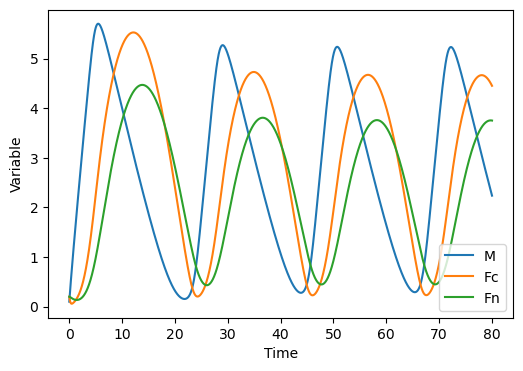

In [8]:
f, ax = plt.subplots(figsize=(6, 4))

ax.plot(solution.t, solution.y[0], label='M')
ax.plot(solution.t, solution.y[1], label='Fc')
ax.plot(solution.t, solution.y[2], label='Fn')
ax.legend()

ax.set_xlabel('Time')
ax.set_ylabel('Variable')

# Task 1 - period of oscillations

In [9]:
t_span = [0, 300]

dt = 0.01 # sec

t_skip = 100 # skip the time interval until steady oscillation amplitude

t_eval = np.arange(t_skip, t_span[1], dt) 

## Subtask 1. Period of oscillations

In [10]:
state_initial = (0.1, 0.2, 0.2)

In [11]:
solution = solve_ivp(model, t_span, state_initial, args=[params,], method='RK45', t_eval=t_eval)

### Find peaks:

In [12]:
from scipy.signal import find_peaks

pks_m , _ = find_peaks(solution.y[0], prominence=4)
pks_fc, _ = find_peaks(solution.y[1], prominence=3)
pks_fn, _ = find_peaks(solution.y[2], prominence=3)

pks = [pks_m, pks_fc, pks_fn]

### Check that peaks are correctly found

Text(0.5, 0, 'Time')

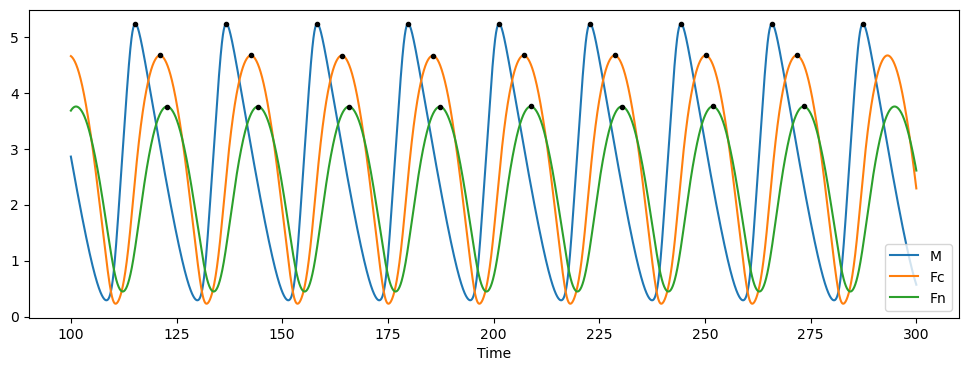

In [13]:
f, ax = plt.subplots(figsize=(12, 4))

for i, lbl, peaks in zip(range(len(state_initial)), ['M', 'Fc', 'Fn'], pks):

    ax.plot(solution.t, solution.y[i], label=lbl)
    
    ax.plot(solution.t[peaks], solution.y[i][peaks], '.k')

ax.legend()

ax.set_xlabel('Time')

### Estimate the period as the avearge time between peaks

In [14]:
periods = dict()

for peaks, varname in zip(pks, ['M', 'Fc', 'Fn']):
    
    peak_times = solution.t[peaks]
    
    period_mean = np.mean(np.diff(peak_times))
    
    periods[varname] = period_mean

periods

{'M': 21.513750000011004, 'Fc': 21.512857142868153, 'Fn': 21.51285714286815}

## Subtask 2: Dependence on Vs

In [15]:
vs_vals = np.arange(0, 2.1, 0.1) # np.arange(0, 2.1, 0.02)

amps = []

for vs in vs_vals:
    
    params.v_s = vs
    
    solution = solve_ivp(model, t_span, state_initial, args=[params,], method='RK45', t_eval=t_eval)
    
    pks_m , _ = find_peaks(solution.y[0], prominence=1) # prominence=0
    
    if pks_m.size > 0:
        M_amplitude = solution.y[0][pks_m].mean() - np.min(solution.y[0]) # assumin the lowest value is defined by the minima of the spikes.
    else:
        M_amplitude = 0
        
    amps.append(M_amplitude)

Text(0.5, 0, '$v_s$')

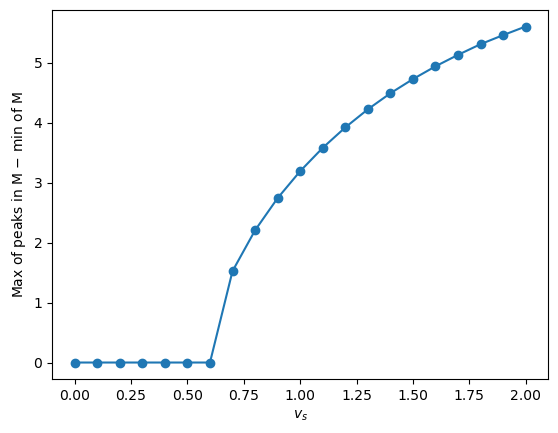

In [16]:
plt.plot(vs_vals, amps, 'o-')
plt.ylabel('Max of peaks in M $-$ min of M')
plt.xlabel('$v_s$')

# Task 2 - 'disruption' of Neurospora's circadian rhythm


 - Modify the model function such that the input parameter $v_s$ changes in time.
 - This function must take a single time value as an input and return a value of $v_s$.
 - Here, we do this the same way as in Neuronal models with varying stimulating current.

### Model function

In [17]:
def model_disrupted(t, state, model_parameters):
    
    """ Neurospora model - Eqs. 2.1-2.3 with changing v_s
    
    Parameters
    ----------
    
        - t : scalar
            Time point.
        
        - state : tuple with 2 elements
            M, Fc, Fn, at which to evaluate 
            their time derivatives.
            
        - model_parameters : collections.namedtuple
            Values of model parameters are attributes
            of `model_parameters`.
            
    Returns
    -------
    
        - tuple with 3 elements
            dM/dt, dFc/dt, dFn/dt
    
    """

    M, Fc, Fn = state
    
    mp = model_parameters
    
    dMdt = mp.v_s(t) * mp.K_l**mp.n / (mp.K_l**mp.n +  Fn**mp.n) - mp.v_m * M / (mp.K_m + M)
    
    dFcdt = mp.k_s * M - mp.v_d * Fc / (Fc + mp.K_d) - mp.k_1 * Fc + mp.k_2 * Fn
    
    dFndt = mp.k_1 * Fc - mp.k_2 * Fn
    
    return dMdt, dFcdt, dFndt

### Make a function returning $v_s$ value, given a time, $t$, and parameters ($v_{\text{s,min}}$, $v_{\text{s,max}}$, period)

In [18]:
def get_vs_value(t, vs_min, vs_max, period=21):
    frequency = 1/period
    vs_vals = np.cos(2*np.pi*frequency*t)
    return vs_max if vs_vals > 0 else vs_min

#### Test the function

Text(0, 0.5, '$v_s$')

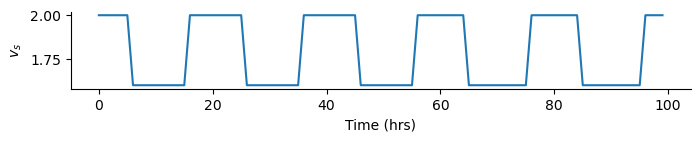

In [19]:
ts = np.arange(0, 100, 1)

vs_vals = np.array([get_vs_value(ti, 1.6, 2, period=20) for ti in ts])

plt.figure(figsize=(8,1))
plt.plot(ts, vs_vals)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Time (hrs)')
plt.ylabel('$v_s$')

#### Assign `get_vs_value` to params.vs

In [20]:
vs_min = 1.6
vs_max = 2
daylight_period = 24 # hrs

params.v_s = lambda t_val : get_vs_value(t_val, vs_min=vs_min, vs_max=vs_max, period=daylight_period)

### Solve the new model

In [21]:
state_initial = (0.1, 0.2, 0.2)

In [22]:
solution = solve_ivp(model_disrupted, [0, 110], state_initial, args=[params,], method='RK45', max_step=0.1)

Text(0, 0.5, 'Variable')

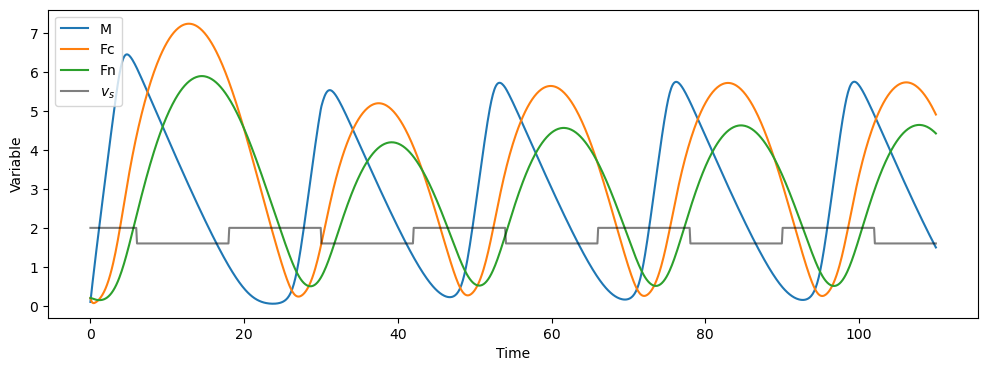

In [23]:
f, ax = plt.subplots(figsize=(12, 4))

for i, lbl, peaks in zip(range(len(state_initial)), ['M', 'Fc', 'Fn'], pks):

    ax.plot(solution.t, solution.y[i], label=lbl)
    
    # ax.plot(solution.t[peaks], solution.y[i][peaks], '.k')

ax.plot(solution.t, [params.v_s(ti) for ti in solution.t], 'k', alpha=0.5, label='$v_s$')
ax.legend()

ax.set_xlabel('Time')
ax.set_ylabel('Variable')

### Increase $v_s^{max}$

In [24]:
tspan = [0, 2000]
t_eval = np.arange(300, tspan[1], dt) 

In [25]:
params.v_s = lambda t_val : get_vs_value(t_val, vs_min=vs_min, vs_max=2.1, period=daylight_period)

In [26]:
solution = solve_ivp(model_disrupted, tspan, state_initial, args=[params,], method='RK45', t_eval=t_eval)

Text(0.5, 0, 'Time')

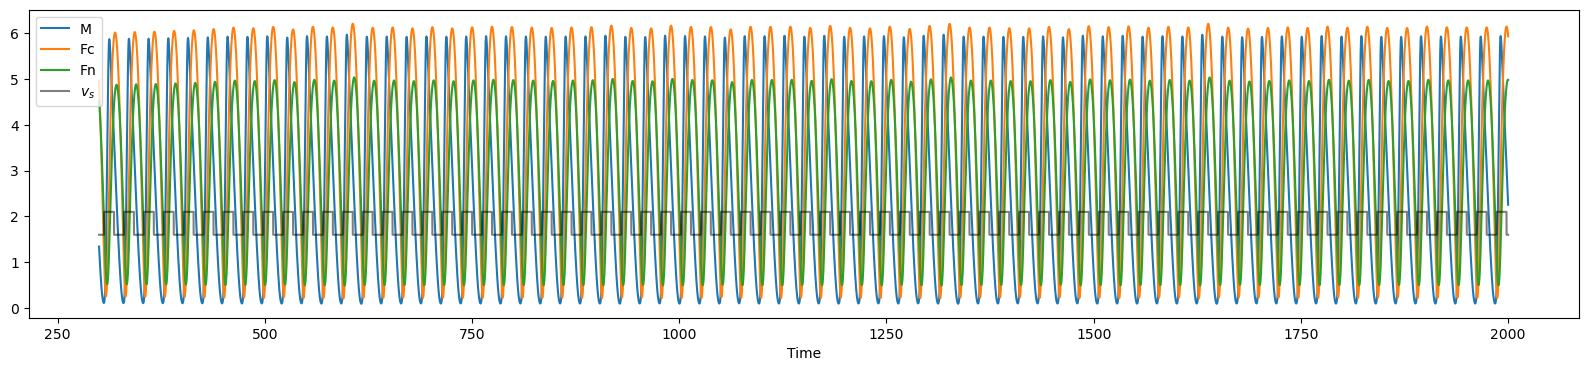

In [27]:
f, ax = plt.subplots(figsize=(20, 4))

for i, lbl, peaks in zip(range(len(state_initial)), ['M', 'Fc', 'Fn'], pks):

    ax.plot(solution.t, solution.y[i], label=lbl)

ax.plot(solution.t, [params.v_s(ti) for ti in solution.t], 'k', alpha=0.5, label='$v_s$')
ax.legend()

ax.set_xlabel('Time')

### Increase $v_s^{max}$ MORE

In [28]:
params.v_s = lambda t_val : get_vs_value(t_val, vs_min=vs_min, vs_max=4.7, period=daylight_period)

In [29]:
solution_ = solve_ivp(model_disrupted, tspan, state_initial, args=[params,], method='RK45', t_eval=t_eval)

Text(0.5, 0, 'Time')

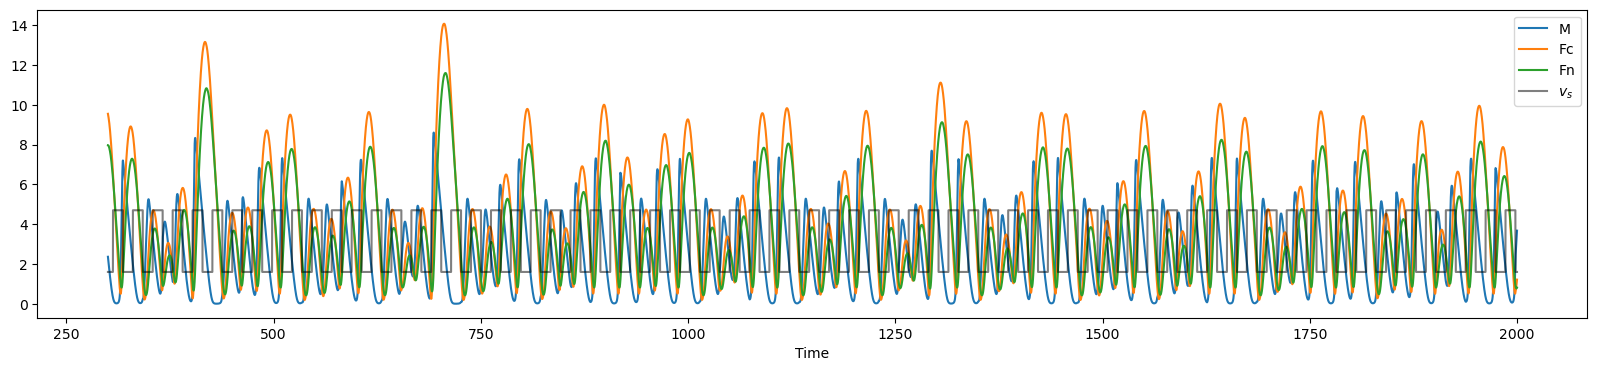

In [30]:
f, ax = plt.subplots(figsize=(20, 4))

for i, lbl, peaks in zip(range(len(state_initial)), ['M', 'Fc', 'Fn'], pks):

    ax.plot(solution_.t, solution_.y[i], label=lbl)

ax.plot(solution.t, [params.v_s(ti) for ti in solution.t], 'k', alpha=0.5, label='$v_s$')
ax.legend()

ax.set_xlabel('Time')

## Phase portraits of the solutions with $v_s^{max}$ = 2.5, $v_s^{max}$ = 4.7

In [31]:
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D projection


In [32]:
# %matplotlib widget # for interactive (need to restart the notebook to switch it off)

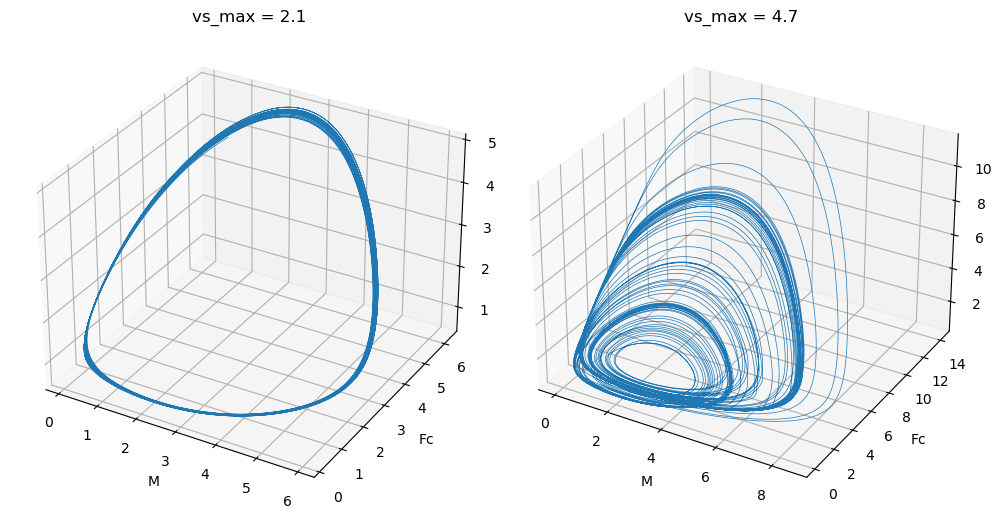

In [33]:
# Create a figure
fig = plt.figure(figsize=(10, 6))

# First 3D subplot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

ax1.plot3D(solution.y[0], solution.y[1],solution.y[2], lw=0.5)
ax1.set_title("vs_max = 2.1")
ax1.set_xlabel('M')
ax1.set_ylabel('Fc')
ax1.set_zlabel('Fn')

# Second 3D subplot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

ax2.plot3D(solution_.y[0], solution_.y[1],solution_.y[2], lw=0.5)
ax2.set_title("vs_max = 4.7")
ax2.set_xlabel('M')
ax2.set_ylabel('Fc')
ax2.set_zlabel('Fn')

plt.tight_layout()
plt.show()


# Task 3 : Adjustment of circadian rhythm

In [34]:
tspan = [0, 1000]
t_eval = np.arange(300, tspan[1], dt) 

vs_min = 1.6
vs_max = 2

In [35]:
T_vals = np.arange(20, 31)
solutions = []

for T_ in T_vals:

    params.v_s = lambda t_val : get_vs_value(t_val, vs_min=vs_min, vs_max=vs_max, period=T_)
    
    solutions.append(solve_ivp(model_disrupted, tspan, state_initial, args=[params,], method='RK45', t_eval=t_eval))

In [36]:
system_periods = np.zeros((T_vals.size, 3))

var_idx = 0 #

for i, solution in enumerate(solutions):
    
    pks, _ = find_peaks(solution.y[var_idx], prominence=2)
    
    peak_times = solution.t[pks]
    
    ### CHECK that the peaks are found correctly:
    # plt.figure()
    # plt.plot(solution.t, solution.y[var_idx])
    # plt.plot(peak_times, solution.y[var_idx][pks], marker='o', ls='', color='r')
    
    period = np.diff(peak_times).mean()
    period_sem = np.diff(peak_times).std() / np.sqrt(peak_times.size)
    
    system_periods[i, :2] = [period, period_sem]
    system_periods[i, 2] = peak_times.size

#### Show results

In [37]:
print("T \t    System period (Mean±SEM)\t Num. peaks\n--------------------------------------------------")
for i, prd in enumerate(system_periods):
    print(f"{T_vals[i]} \t\t {prd[0]:.2f} ± {prd[1]:.2f} \t\t    {int(prd[2])}")

T 	    System period (Mean±SEM)	 Num. peaks
--------------------------------------------------
20 		 21.77 ± 0.20 		    32
21 		 21.09 ± 0.10 		    33
22 		 22.01 ± 0.05 		    31
23 		 23.00 ± 0.01 		    31
24 		 24.00 ± 0.00 		    29
25 		 23.04 ± 0.26 		    30
26 		 22.68 ± 0.26 		    31
27 		 22.48 ± 0.26 		    31
28 		 22.40 ± 0.28 		    31
29 		 22.55 ± 0.25 		    31
30 		 22.53 ± 0.25 		    30


#### Plot T - System period vs T

Text(0, 0.5, 'T $-$ system period (h)')

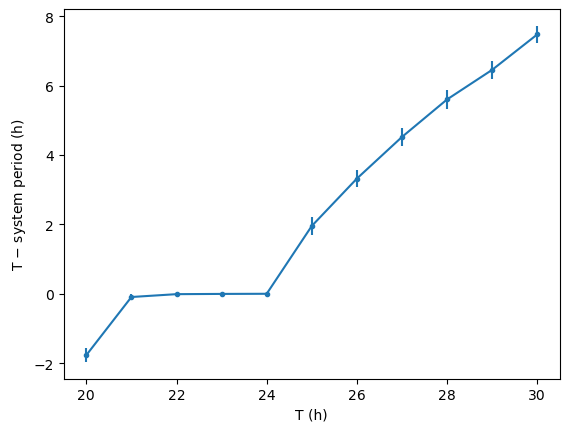

In [39]:
f,ax = plt.subplots()
ax.errorbar(T_vals, T_vals - system_periods[:, 0], yerr=system_periods[:, 1], marker='.')
ax.set_xlabel('T (h)')
ax.set_ylabel('T $-$ system period (h)')

# Bonus real-life exercise of Neurospora world

About a century ago, the introduction of the electric light changed peoples' lifes: it became possible to party all-night, walk through streets at night, and do work at night. This lengthened the duration of the light exposure of our eyes and shortened the time when our eyes are in darkness. Imagine, that a peculiar population of Neurospora made the same innovation in their lives. How their circadian rhythms would change? Try to model this:

 - Modify the function `get_vs_value` so that it returns v_s value corresponding to "day" longer time than half the `period` parameter, and v_s value corresponding to "night" shorter than half of the `period`. This would model lengthened exposure of neurosphora to light from, e.g., lights illuminating neurospora-world-highways, neurospora-phones, or their TVs.
 - Keep the `period` parameter in this function 24h: Earth keeps rotating with the same speed as before.
 - Simulate the model during a time that allows you to see multiple periods of the system.
 - Did anything change in the model? If no, try further increasing the light time and shortening the dark time. Ultimately, this may model some sort of "sleep deprivation" for Neurospora...